In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import src.statsmodels as statsmodels 
import copy


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
!ls binaural_unit_activations

word_task_half_co_loc_v08_gender_bal_4M_sanity
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout


In [3]:
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
for key in h5.keys():
    print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

In [4]:
### Get layer shape dict 

layer_shape_dict = pickle.load(open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb"))
# batch got saved, drop batch dim in layer_shape_dict
layer_shape_dict = {k: v[1:] for k,v in layer_shape_dict.items() if 'gains' not in k}

In [5]:
# ## Plot distribution of gains 
# # gain_keys = [key for key in h5.keys() if "gain" in key]
# gain_keys = ['attncoch_gains',
# 'attn1_gains',
#  'attn2_gains',
#  'attn3_gains',
#  'attn4_gains',
#  'attn5_gains',
#  'attn6_gains',
#  'attnfc_gains']

# # get number of subplots for gains 
# n_gains = len(gain_keys)
# n_rows = int(np.ceil(n_gains/2))
# n_cols = 2
# fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
# axs = axs.flatten()
# for ix, key in enumerate(gain_keys):
#     sns.histplot(data=h5[key][:].flatten(), bins=30, stat='proportion', ax=axs[ix])
#     axs[ix].set_title(key)

# plt.tight_layout()


### For spatial tuning analysis, average over examples presented at same location, and compare across locations. 



In [6]:
### get binning for pitch classes 

import numpy as np
import matplotlib.pyplot as plt

def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# # Plot the histogram with the optimal number of bins
# plt.hist(target_f0s, bins=optimal_bins)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Count')
# plt.title('Optimal Histogram Binning')
# plt.show()

Optimal number of bins: 9


In [7]:
optimal_bins

9

9 10


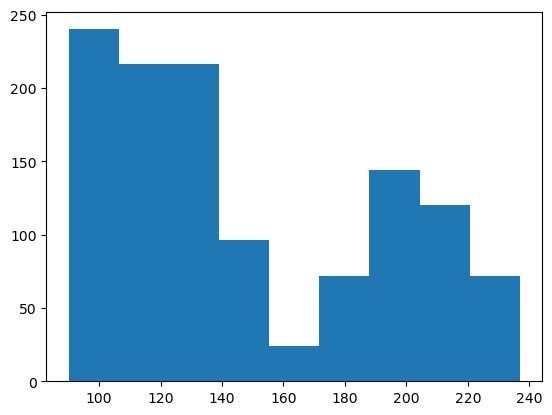

In [8]:
## Get spatial selectivity for each layer
## Get ixs corresponding to locations
#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
location_ixs = {}
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        location_ixs['front'] = loc_ixs
    elif elev == 0:
        location_ixs[f"{azim} azim"] = loc_ixs
    elif azim == 0:
        location_ixs[f"{elev} elev"] = loc_ixs


# get pitch labeling  
## Need to bin f0 into categories
# find number of bins that has roughly equal number of examples per bin 

outs = plt.hist(target_f0s, bins=optimal_bins)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

class_assignments = {**location_ixs, **f0_ixs}

### Run and plot 2 way anova for each layer 

In [9]:
### init common labeling 

loc_list = np.zeros(len(target_locs), dtype=object)
for loc, loc_ixs in location_ixs.items():
    loc_list[loc_ixs] = loc

f0_list = [f"{bin} Hz" for bin in f0_bins]


In [10]:
## get anova results for each unit in each layer 
n_cats = 5 # will be for location, f0, interaction, residual, total

anova_results = {}
for layer_ix in np.arange(7):
    layer_name = f'hann_pool_{layer_ix}_cue'
    print(f"Parsing {layer_name}")

    layer_acts = h5[layer_name][:]
    n_units = layer_acts.shape[-1]
    n_examples = layer_acts.shape[0]
    dependent_var = layer_acts.flatten()
    unit_ix = np.arange(layer_acts.shape[-1])
    unit_ix = np.tile(unit_ix, n_examples)

    # make dataframe 
    act_df = pd.DataFrame(dependent_var, columns=['activation'])
    act_df['unit_ix'] = unit_ix
    act_df['f0'] = np.repeat(f0_list, n_units)
    act_df['location'] = np.repeat(loc_list, n_units)
    act_df['interaction'] = act_df['f0'] + ' ' + act_df['location']

    results_to_plot_prop = np.zeros((n_units, n_cats))
    results_to_plot = np.zeros((n_units, n_cats))

    for unit in range(n_units):
        anova = statsmodels.NWayANOVA(act_df[act_df.unit_ix == unit], 'activation', ['location', 'f0'])
        results = anova.perform_anova()
        results_to_plot[unit] = results['SS']
        results_to_plot_prop[unit] = results['prop_SS']
    # save results to dict
    anova_results[layer_name] = {'raw_SS':results_to_plot,
                                'prop_SS':results_to_plot_prop}


Parsing hann_pool_0_cue
Parsing hann_pool_1_cue
Parsing hann_pool_2_cue
Parsing hann_pool_3_cue


/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:472: RuntimeWarning: invalid value encountered in scalar divide
  self.F = {var: self.MSA[var] / self.MSE for var in self.independent_vars}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:473: RuntimeWarning: invalid value encountered in scalar divide
  self.F_interactions = {interaction: self.MS_interactions[interaction] / self.MSE for interaction in self.MS_interactions}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:497: RuntimeWarning: invalid value encountered in divide
  self.results['prop_SS'].append(self.SSA[var] / self.SST)
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:506: RuntimeWarning: invalid value encountered in scalar divide
  self.results['prop_SS'].append(self.SS_interactions[interaction] / self.SST)
/net/vast-storage/scratch/vast/mcderm

Parsing hann_pool_4_cue


/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:472: RuntimeWarning: invalid value encountered in scalar divide
  self.F = {var: self.MSA[var] / self.MSE for var in self.independent_vars}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:473: RuntimeWarning: invalid value encountered in scalar divide
  self.F_interactions = {interaction: self.MS_interactions[interaction] / self.MSE for interaction in self.MS_interactions}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:497: RuntimeWarning: invalid value encountered in divide
  self.results['prop_SS'].append(self.SSA[var] / self.SST)
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:506: RuntimeWarning: invalid value encountered in scalar divide
  self.results['prop_SS'].append(self.SS_interactions[interaction] / self.SST)
/net/vast-storage/scratch/vast/mcderm

Parsing hann_pool_5_cue


/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:472: RuntimeWarning: invalid value encountered in scalar divide
  self.F = {var: self.MSA[var] / self.MSE for var in self.independent_vars}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:473: RuntimeWarning: invalid value encountered in scalar divide
  self.F_interactions = {interaction: self.MS_interactions[interaction] / self.MSE for interaction in self.MS_interactions}
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:497: RuntimeWarning: invalid value encountered in divide
  self.results['prop_SS'].append(self.SSA[var] / self.SST)
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/statsmodels.py:506: RuntimeWarning: invalid value encountered in scalar divide
  self.results['prop_SS'].append(self.SS_interactions[interaction] / self.SST)
/net/vast-storage/scratch/vast/mcderm

Parsing hann_pool_6_cue


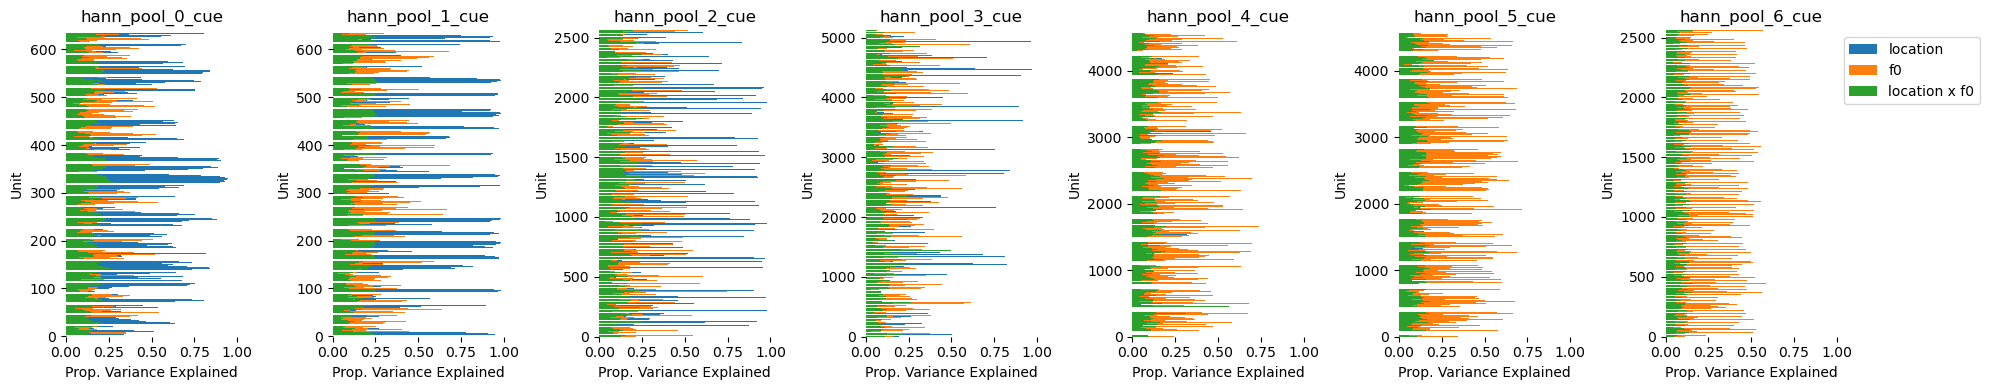

In [22]:
# plot results to plot as cumulative bar plot 
# each row is a unit, each column is a category
# each bar is the proportion of SS explained by that category
# bars are stacked on top of each other
# x axis is proportion of SS explained
# y axis is unit number
# color is category

fig, ax = plt.subplots(1, 7, figsize=(20, 4))

n_cats = 3 # will be for location, f0, interaction
# bottom = np.zeros(n_units)
cat_labels = ['location', 'f0', 'location x f0']
for layer_ix, (layer_name, results) in enumerate(anova_results.items()):
    results_to_plot_prop = results['prop_SS']
    n_units = results_to_plot_prop.shape[0]
    for cat_ix in range(n_cats):
        # sns.barplot(x=np.arange(n_units), y=results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", ax=ax[layer_ix], orient='h', label=cat_labels[cat_ix])
        ax[layer_ix].barh(np.arange(n_units), results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", label=cat_labels[cat_ix])
        # bottom += results_to_plot_prop[:, cat_ix]
    ax[layer_ix].set_xlabel('Prop. Variance Explained')
    ax[layer_ix].set_ylabel('Unit')
    ax[layer_ix].set_title(layer_name)
    ax[layer_ix].set_ylim(0, n_units)
    ax[layer_ix].set_xlim(0, 1)

    if layer_ix < 6:
        # remove legend for all but last plot
        ax[layer_ix].legend().set_visible(False)
    else:
        ax[layer_ix].legend(loc='upper left', bbox_to_anchor=(1, 1))

    # move legend outside of plot
sns.despine(left=True, bottom=True)

plt.tight_layout()



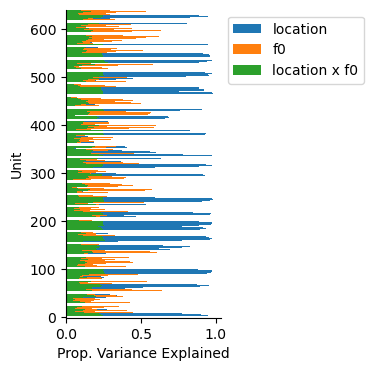

In [ ]:
# plot results to plot as cumulative bar plot 
# each row is a unit, each column is a category
# each bar is the proportion of SS explained by that category
# bars are stacked on top of each other
# x axis is proportion of SS explained
# y axis is unit number
# color is category

fig, ax = plt.subplots(figsize=(2, 4))
bottom = np.zeros(n_units)
cat_labels = ['location', 'f0', 'location x f0']
for cat_ix, cat_label in enumerate(cat_labels):
    ax.barh(np.arange(n_units), results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", label=cat_label)

ax.set_xlabel('Prop. Variance Explained')
ax.set_ylabel('Unit')
ax.set_ylim(-1, n_units)
# move legend outside of plot
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
sns.despine()

In [ ]:
results_to_plot.argmin(axis=0)

array([420, 420, 420, 617, 420])